# 0 - Import libraries

In [19]:
import tamubo.exactbo as ebo
import cupynumeric as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from partition_cupynumeric import split_boxes
from bound_cupynumeric import rbf_k_bounds
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

# 1 - Define initial steps as usual

In [20]:
# Define model
kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=0.2, length_scale_bounds=(1e-2, 10.0)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-10, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, normalize_y=True)

# Define bounds
bounds = [[0,1],[0,1]]

# Define initial box
init_box = ebo.Box(bounds,True)

# Function to minimize
# f(x,y)= \alpha(x^2 + y^2) - \sum_{i=1}^3 A_i \exp \left( -\frac{(x - Cx_i)^2 + (y - Cy_i)^2}{B_i} \right) + D
def f(X):
    x, y = X[:,0], X[:,1]

    # Parameters
    alpha = 0.1
    A  = np.array([4, 3, 2])
    B  = np.array([0.08, 0.05, 0.02])    # betas
    C  = np.array([[0.9, 0.3 ],      # centers (x1,y1)
                [0.1 , 0.8],
                [0.6 , 0.7 ]])
    D = 2
    
    # Compute function value
    val = alpha*(x**2 + y**2)
    for Ai, Bi, (xi, yi) in zip(A, B, C):
        r2 = (x - xi)**2 + (y - yi)**2
        val -= Ai * np.exp(-r2 / Bi)
    val += D
    return val

# Create initial points and evaluate
X0 = np.array([[0,0],[1,1],[0.5,0.5],[0,1],[1,0]])
X0_cp = cp.array(X0.tolist())

N = X0.shape[0]

y0 = f(X0)

# Train model
gp.fit(X0,y0.ravel())

# Get information from gp
gp_kernel_params = gp.kernel_.get_params()
sigma_f_2 = gp_kernel_params['k1__k1__constant_value']
length_scale = gp_kernel_params['k1__k2__length_scale']
sigma_n_2 = gp_kernel_params['k2__noise_level']
alpha = cp.array(gp.alpha_)

# Define boxes object
boxes = ebo.Boxes([init_box])

# Number of boxes
n = len(boxes)
d = init_box.dim
w = cp.array(init_box.width)

# Boxes bounds to cupynumeric
boxes_bounds = boxes.bounds.reshape(n*d,2)
boxes_bounds_L = cp.array(boxes_bounds[:,0].reshape(n,d))
boxes_bounds_R = cp.array(boxes_bounds[:,1].reshape(n,d))

# 2 - Developing mean bounds function

In [21]:
def mu_bounds(alpha,K_lo,K_hi):
    alphaK_lo = cp.zeros((n,N))
    alphaK_hi = cp.zeros((n,N))
    
    alpha_mask_pos = alpha >= 0

    # when alpha >= 0: hi→hi, lo→lo
    alphaK_hi[:, alpha_mask_pos] = K_hi[:, alpha_mask_pos] * alpha[alpha_mask_pos]
    alphaK_lo[:, alpha_mask_pos] = K_lo[:, alpha_mask_pos] * alpha[alpha_mask_pos]

    # when alpha < 0: hi→lo, lo→hi
    alphaK_lo[:, ~alpha_mask_pos] = K_hi[:, ~alpha_mask_pos] * alpha[~alpha_mask_pos]
    alphaK_hi[:, ~alpha_mask_pos] = K_lo[:, ~alpha_mask_pos] * alpha[~alpha_mask_pos]

    # sum each row
    mu_hi = alphaK_hi.sum(axis=1)  # shape (n,)
    mu_lo = alphaK_lo.sum(axis=1)  # shape (n,)

    return(mu_lo, mu_hi)

# 3 - Partition and Bound Loop

In [22]:
# Loop over different amount of boxes
ns = []
#times = []
Ls = []
Rs = []
K_los = []
K_his = []
mu_los = []
mu_his = []
for _ in range(2):
    n = boxes_bounds_L.shape[0]

    # Find kernel bounds (timing it)
    #start_time = time()
    K_lo = cp.zeros((n,N))
    K_hi = cp.zeros((n,N))
    for i in range(N):
        xi = X0_cp[i]
        K_lo[:,i], K_hi[:,i] = rbf_k_bounds(boxes_bounds_L.ravel(),boxes_bounds_R.ravel(),xi,n,d,sigma_f_2,length_scale)
    #end_time = time()

    mu_lo, mu_hi = mu_bounds(alpha,K_lo,K_hi)

    # Save results
    ns.append(n)
    #times.append((end_time-start_time)/1e6)
    Ls.append(boxes_bounds_L)
    Rs.append(boxes_bounds_R)
    K_los.append(K_lo)
    K_his.append(K_hi)
    mu_los.append(mu_lo)
    mu_his.append(mu_hi)

    # Split boxes
    boxes_bounds_L, boxes_bounds_R = split_boxes(boxes_bounds_L, boxes_bounds_R, w, n, d)

In [23]:
mu_los

[array([-2.21808434]),
 array([-1.15246121, -1.0687673 , -0.10064782, -0.10849053, -0.01819246])]

In [24]:
mu_his

[array([2.21808317]),
 array([0.92140184, 1.30121793, 0.08856454, 0.12437556, 0.02229447])]

# 4 - Plotting

In [17]:
def plot_rectangles(L, R, pad=0.01):
    L = np.asarray(L)
    R = np.asarray(R)
    assert L.shape == R.shape and L.shape[1] == 2

    widths = R[:, 0] - L[:, 0]
    heights = R[:, 1] - L[:, 1]

    inset_ll = L + pad
    inset_w = np.maximum(widths - 2 * pad, 0)
    inset_h = np.maximum(heights - 2 * pad, 0)

    fig, ax = plt.subplots()
    for (x, y), w, h in zip(inset_ll, inset_w, inset_h):
        ax.add_patch(Rectangle((x, y), w, h,
                               fill=False,
                               linewidth=2.0,
                               edgecolor='C0'))
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    plt.show()


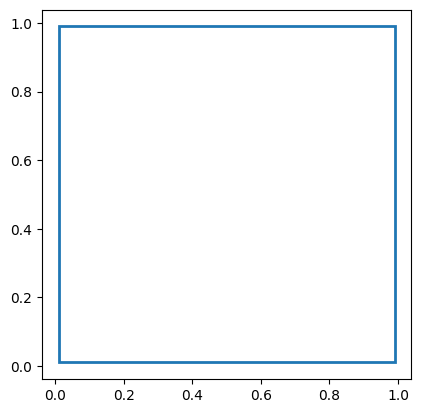

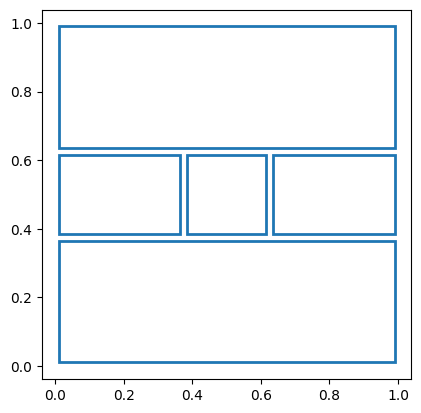

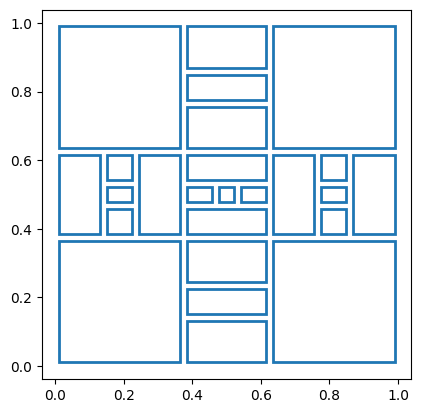

In [18]:
plot_rectangles(Ls[0],Rs[0])
plot_rectangles(Ls[1],Rs[1])
plot_rectangles(Ls[2],Rs[2])